# Mention-spike event study

This notebook tests whether unusually high media attention is followed by different stock behaviour in the following week.

**Financial question:** When a company has an unusually high number of news mentions in a week, does its stock show a larger next-week absolute return or a different next-week signed return?

The notebook uses a ticker-level paired design. For each ticker, we compare its own next-week behaviour after spike weeks against its own next-week behaviour after normal weeks. We then test the cross-sectional mean of these ticker-level differences.

We define attention spikes as ticker-specific top-decile weekly mention counts. This means that each company is compared to its own normal media-attention level, rather than using the same raw mention threshold for all firms.

We require at least 20 total mentions, 3 spike weeks, and 20 normal weeks so that each ticker has a minimally reliable event and baseline sample. The main statistical tools are the one-sample t-test, Shapiro-Wilk normality check, and Wilcoxon signed-rank robustness check.


In [12]:
from pathlib import Path
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = Path('.').resolve()
PROJECT = HERE.parents[1]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

MIN_TOTAL_MENTIONS = 20
MIN_SPIKE_WEEKS = 3
MIN_NORMAL_WEEKS = 20
SPIKE_QUANTILE = 0.90

## 1. Load articles, company database, and returns

In [13]:
articles = pd.read_csv(PROJECT / 'companies_in_articles.csv')
company_db = pd.read_csv(PROJECT / 'nyse_nasdaq_companies_list.csv')
daily_ret = pd.read_csv(HERE / 'daily_returns_2017_2019.csv', index_col=0, parse_dates=True)

articles['date'] = pd.to_datetime(articles['date'], errors='coerce')
articles = articles.dropna(subset=['date'])

print(f'articles with dates: {len(articles):,}')
print(f'company database rows: {len(company_db):,}')
print(f'daily return panel: {daily_ret.shape[0]:,} days x {daily_ret.shape[1]:,} tickers')


articles with dates: 48,259
company database rows: 4,189
daily return panel: 752 days x 724 tickers


## 2. Map article company mentions to stock tickers

The article file contains raw company names, while the return table is indexed by stock tickers. This step builds a conservative alias dictionary from the company database, normalises raw mention strings, and maps each article-company mention to a ticker.

The output is **one row per article-ticker pair**. For example, if an article contains:

```text
article_id = 10
date = 2018-04-15
company = ['Apple', 'Microsoft', 'Amazon']
```

then the mapping gives:

```text
Apple     -> AAPL
Microsoft -> MSFT
Amazon    -> AMZN
```

and the output becomes:

```text
article_id   date          ticker
10           2018-04-15    AAPL
10           2018-04-15    MSFT
10           2018-04-15    AMZN
```

If the same ticker appears several times in one article under different names, we keep it only once. For example:

```text
company = ['Apple', 'Apple Inc.', 'AAPL']
```

produces only:

```text
article_id   date          ticker
10           2018-04-15    AAPL
```

To avoid ambiguous matches, aliases that map to more than one ticker are removed. Finally, we keep only tickers that are present in the daily return panel, because the event study needs stock-return data.
```

In [14]:
LEGAL_SUFFIXES = r"""
inc|inc\.|corporation|corp|corp\.|company|co|co\.|group|plc|ltd|ltd\.|limited|
holdings|holding|sa|s\.a\.|ag|nv|n\.v\.|se|spa|s\.p\.a\.|asa|ab|gmbh|lp|llp|llc|l\.l\.c\.|bv|b\.v\.
"""
suffix_re = re.compile(rf'\b({LEGAL_SUFFIXES})\b', re.IGNORECASE | re.VERBOSE)

def normalize_name(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    x = x.replace("'s", '')
    x = re.sub(r'\.[A-Z]+$', '', x)
    x = x.lower().replace('&', ' and ')
    x = suffix_re.sub(' ', x)
    x = re.sub(r'[^a-z0-9 ]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x or None

alias_rows = []
for _, row in company_db.iterrows():
    for col in ['company', 'search_name', 'ticker']:
        if col not in company_db.columns:
            continue
        val = row.get(col)
        if pd.isna(val):
            continue
        alias = normalize_name(val)
        if alias and len(alias) >= 3:
            alias_rows.append((alias, row.get('ticker', '')))

alias_df = pd.DataFrame(alias_rows, columns=['alias', 'ticker']).drop_duplicates()
alias_df = alias_df[alias_df['ticker'].notna() & (alias_df['ticker'].astype(str).str.len() > 0)]
unique_counts = alias_df.groupby('alias')['ticker'].nunique()
alias_df = alias_df[alias_df['alias'].isin(unique_counts[unique_counts == 1].index)]
alias_to_ticker = dict(zip(alias_df['alias'], alias_df['ticker'].astype(str)))

def parse_company_list(x):
    if pd.isna(x):
        return []
    s = str(x)
    if s.startswith('['):
        try:
            parsed = ast.literal_eval(s)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return [s]

articles['companies'] = articles['company'].apply(parse_company_list)

rows = []
for article_id, date, companies in zip(articles['article_id'], articles['date'], articles['companies']):
    seen = set()
    for company in companies:
        ticker = alias_to_ticker.get(normalize_name(company))
        if ticker and ticker not in seen:
            seen.add(ticker)
            rows.append((article_id, date, ticker))

article_tickers = pd.DataFrame(rows, columns=['article_id', 'date', 'ticker'])
article_tickers = article_tickers[article_tickers['ticker'].isin(daily_ret.columns)].copy()

print(f'article-ticker rows matched to return panel: {len(article_tickers):,}')
article_tickers.head()

article-ticker rows matched to return panel: 17,282


,article_id,date,ticker
0,0,2018-04-26,HMC
3,2,2018-04-10,C
5,6,2018-05-04,ALK
7,7,2018-05-08,BCRX
9,8,2018-05-31,PSO


## 3. Build weekly mention and return time series

This step puts the text data and the financial data on the same weekly scale.

First, each article date is converted to a calendar week. Then, for each ticker and week, we count how many unique articles mentioned that ticker. This gives the weekly attention variable:

```text
weekly mentions = number of articles mentioning a ticker in a given week
```

For example, if Apple is mentioned in three different articles during the same week:

```text
article_id   date          ticker
10           2018-04-10    AAPL
15           2018-04-11    AAPL
21           2018-04-13    AAPL
```

then the weekly mention table becomes:

```text
ticker   week                    mentions
AAPL     2018-04-09/2018-04-15   3
```

Second, daily stock log-returns are summed by week. This is valid because log-returns are additive over time:

```text
weekly log-return = sum of daily log-returns in that week
```

For example:

```text
date          AAPL daily log-return
2018-04-09    0.010
2018-04-10   -0.005
2018-04-11    0.002
2018-04-12    0.001
2018-04-13    0.004
```

becomes:

```text
week                    AAPL weekly return
2018-04-09/2018-04-15   0.012
```

The next cell will use these weekly time series to define spike weeks and compute next-week returns.
```

In [15]:
article_tickers['week'] = article_tickers['date'].dt.to_period('W')
weekly_mentions = (article_tickers.groupby(['ticker', 'week'])['article_id']
    .nunique().rename('mentions').reset_index())

weekly_returns = daily_ret.resample('W').sum()
weekly_returns.index = weekly_returns.index.to_period('W')

print(f'weekly mention rows: {len(weekly_mentions):,}')
print(f'weekly return panel: {weekly_returns.shape[0]:,} weeks x {weekly_returns.shape[1]:,} tickers')

weekly mention rows: 5,613
weekly return panel: 157 weeks x 724 tickers


## 4. Define mention-spike weeks and compute ticker-level effects

This is the main event-study construction step.

For each ticker, we build a weekly panel with two variables:

```text
mentions = number of articles mentioning the ticker in week t
return   = stock log-return in week t
```

Then we create two forward-looking variables:

```text
next_week_return     = stock return in week t+1
next_week_abs_return = absolute value of stock return in week t+1
```

The idea is to test whether an unusually high mention week is followed by abnormal stock behaviour in the following week.

### How a spike week is defined

A spike week is defined separately for each ticker. We do not use the same raw threshold for all companies, because large companies naturally receive more news than smaller companies.

For each ticker:

1. Keep only weeks where the ticker has at least one mention.
2. Compute the ticker-specific 90th percentile of weekly mention counts.
3. Define a spike week as a week where:

```text
mentions >= ticker-specific 90th percentile
```

For example, if Apple's positive weekly mention counts are:

```text
2, 3, 4, 5, 8, 10, 20, 40
```

then its spike threshold might be around the top 10% of those values. For a smaller company, the threshold could be much lower. This makes the spike definition relative to each company's normal media attention.

### Filters

A ticker is included only if it has enough data to make the comparison meaningful:

- at least `MIN_TOTAL_MENTIONS` total mentions,
- at least `MIN_SPIKE_WEEKS` spike weeks,
- at least `MIN_NORMAL_WEEKS` normal weeks,
- available weekly stock returns.

This is why the final number of tickers is much smaller than the number of companies in the full dataset. We keep only tickers with enough mention history to define spike and normal periods.

### What the output table means

The final table, `ticker_effects`, has one row per ticker. Each row compares that ticker's own spike weeks against its own normal weeks.

The main columns are:

- `ticker`: stock ticker.
- `threshold`: the ticker-specific mention count needed for a week to be classified as a spike week.
- `n_spike_weeks`: number of weeks classified as spike weeks for that ticker.
- `n_normal_weeks`: number of non-spike weeks used as the ticker's baseline.
- `total_mentions`: total number of article mentions for that ticker in the weekly panel.

The return columns are:

- `spike_abs_return_mean`: average `next_week_abs_return` after spike weeks.
  
  This measures how much the stock moved, on average, in the week after high-attention weeks, ignoring direction.

- `normal_abs_return_mean`: average `next_week_abs_return` after normal weeks.
  
  This is the ticker's normal next-week absolute movement.

- `abs_return_diff`: difference between the two:

```text
abs_return_diff = spike_abs_return_mean - normal_abs_return_mean
```

  If this value is positive, the stock moved more after spike weeks than after normal weeks.  
  If it is negative, the stock moved less after spike weeks than after normal weeks.

- `spike_return_mean`: average signed next-week return after spike weeks.
  
  This keeps the direction of the movement.

- `normal_return_mean`: average signed next-week return after normal weeks.

- `return_diff`: difference between signed returns:

```text
return_diff = spike_return_mean - normal_return_mean
```

  If this value is positive, returns were higher after spike weeks.  
  If it is negative, returns were lower after spike weeks.

In [16]:
ticker_results = []
event_rows = []

candidate_tickers = (weekly_mentions.groupby('ticker')['mentions']
                     .sum().sort_values(ascending=False))
candidate_tickers = candidate_tickers[candidate_tickers >= MIN_TOTAL_MENTIONS].index

for ticker in candidate_tickers:
    if ticker not in weekly_returns.columns:
        continue
    mention_series = (weekly_mentions[weekly_mentions['ticker'] == ticker]
        .set_index('week')['mentions'])
    mention_series = mention_series.reindex(weekly_returns.index, fill_value=0)
    returns = weekly_returns[ticker]
    panel = pd.DataFrame({
        'mentions': mention_series,
        'return': returns,
    }).dropna()
    panel['next_week_return'] = panel['return'].shift(-1)
    panel['next_week_abs_return'] = panel['next_week_return'].abs()
    panel = panel.dropna(subset=['next_week_return', 'next_week_abs_return'])
    if panel['mentions'].sum() < MIN_TOTAL_MENTIONS:
        continue
    positive_mentions = panel.loc[panel['mentions'] > 0, 'mentions']
    if len(positive_mentions) < MIN_SPIKE_WEEKS:
        continue
    threshold = max(1, positive_mentions.quantile(SPIKE_QUANTILE))
    panel['is_spike'] = panel['mentions'] >= threshold
    spike = panel[panel['is_spike']]
    normal = panel[~panel['is_spike']]
    if len(spike) < MIN_SPIKE_WEEKS or len(normal) < MIN_NORMAL_WEEKS:
        continue

    mean_spike_abs = spike['next_week_abs_return'].mean()
    mean_normal_abs = normal['next_week_abs_return'].mean()
    mean_spike_ret = spike['next_week_return'].mean()
    mean_normal_ret = normal['next_week_return'].mean()

    ticker_results.append({
        'ticker': ticker,
        'threshold': threshold,
        'n_spike_weeks': len(spike),
        'n_normal_weeks': len(normal),
        'total_mentions': int(panel['mentions'].sum()),
        'spike_abs_return_mean': mean_spike_abs,
        'normal_abs_return_mean': mean_normal_abs,
        'abs_return_diff': mean_spike_abs - mean_normal_abs,
        'spike_return_mean': mean_spike_ret,
        'normal_return_mean': mean_normal_ret,
        'return_diff': mean_spike_ret - mean_normal_ret,
    })

    for week, row in spike.iterrows():
        event_rows.append({
            'ticker': ticker,
            'week': str(week),
            'mentions': row['mentions'],
            'next_week_return': row['next_week_return'],
            'next_week_abs_return': row['next_week_abs_return'],
        })

ticker_effects = pd.DataFrame(ticker_results)
spike_events = pd.DataFrame(event_rows)

print(f'tickers passing filters: {len(ticker_effects):,}')
ticker_effects.sort_values('total_mentions', ascending=False).head(10)

tickers passing filters: 84


,ticker,threshold,n_spike_weeks,n_normal_weeks,total_mentions,spike_abs_return_mean,normal_abs_return_mean,abs_return_diff,spike_return_mean,normal_return_mean,return_diff
0,AAPL,49.5,3,153,672,0.022743,0.025492,-0.002749,0.008247,0.006054,0.002193
1,AMZN,43.6,3,153,586,0.032399,0.025789,0.006610,-0.020382,0.005901,-0.026282
2,GOOGL,40.2,3,153,515,0.051231,0.022800,0.028430,-0.044389,0.004037,-0.048426
3,GS,33.1,3,153,405,0.054398,0.026094,0.028304,-0.036695,0.000608,-0.037303
4,MS,24.0,4,152,388,0.045992,0.026538,0.019455,-0.045992,0.002658,-0.048651
5,MSFT,25.7,3,153,363,0.027952,0.018990,0.008962,0.023344,0.005904,0.017440
6,DB,20.9,3,153,329,0.058302,0.035628,0.022674,-0.058302,-0.003839,-0.054463
7,NYT,19.0,4,152,283,0.030268,0.028449,0.001819,-0.009079,0.006103,-0.015182
8,TSLA,20.0,4,152,272,0.029059,0.051367,-0.022308,0.011956,0.003592,0.008364
9,C,18.0,5,151,247,0.039268,0.025371,0.013897,-0.004836,0.002391,-0.007227


## 5. Test A: do mention spikes increase next-week absolute returns?

For each ticker, we already computed:

```text
abs_return_diff = spike_abs_return_mean - normal_abs_return_mean
```

This measures whether the stock moved more after spike weeks than after normal weeks.

For each ticker, we first compute one summary value: the average next-week absolute return after spike weeks minus the average next-week absolute return after normal weeks. The statistical test is then run on these ticker-level differences. This way, Apple counts once, Microsoft counts once, etc., instead of letting frequently mentioned companies dominate the test.

The hypotheses are:

```text
H0: mean abs_return_diff = 0
H1: mean abs_return_diff > 0
```

So we are testing whether mention-spike weeks are followed by significantly larger next-week absolute returns.

We first check normality with the Shapiro-Wilk test. If the sample is normal enough, or if the sample size is large enough for the Central Limit Theorem to help, we use a one-sample t-test. Otherwise, we use the Wilcoxon signed-rank test as a fallback. The Wilcoxon test is also reported as a robustness check.
```

In [17]:
def one_sample_test_with_hierarchy(x, alternative='greater'):
    x = pd.Series(x).dropna().to_numpy()
    sw = stats.shapiro(x) if len(x) <= 5000 else stats.shapiro(rng.choice(x, size=5000, replace=False))
    if sw.pvalue >= 0.05 or len(x) >= 30:
        chosen = 'one-sample t-test'
        result = stats.ttest_1samp(x, popmean=0.0, alternative=alternative)
    else:
        chosen = 'Wilcoxon signed-rank fallback'
        result = stats.wilcoxon(x, alternative=alternative)
    wilcoxon = stats.wilcoxon(x, alternative=alternative)
    return {
        'chosen_test': chosen,
        'n': len(x),
        'mean_diff': float(np.mean(x)),
        'median_diff': float(np.median(x)),
        'shapiro_W': sw.statistic,
        'shapiro_p': sw.pvalue,
        'test_stat': result.statistic,
        'p_value': result.pvalue,
        'wilcoxon_sensitivity_stat': wilcoxon.statistic,
        'wilcoxon_sensitivity_p': wilcoxon.pvalue,
    }

abs_test = one_sample_test_with_hierarchy(ticker_effects['abs_return_diff'], alternative='greater')
pd.Series(abs_test)

chosen_test                  one-sample t-test
n                                           84
mean_diff                             0.005656
median_diff                           0.006733
shapiro_W                             0.991342
shapiro_p                             0.854345
test_stat                             3.184846
p_value                                0.00102
wilcoxon_sensitivity_stat               2500.0
wilcoxon_sensitivity_p                0.000714
dtype: object

## 6. Test B: do mention spikes predict signed next-week returns?

The previous test used absolute returns, so it measured the **size** of the stock movement after spike weeks, regardless of direction.

Here we test signed returns instead. For each ticker, we use:

```text
return_diff = spike_return_mean - normal_return_mean
```

This compares the average next-week return after spike weeks with the average next-week return after normal weeks.

The hypotheses are:

```text
H0: mean return_diff = 0
H1: mean return_diff ≠ 0
```

We use a two-sided test because a mention spike could correspond to either good news or bad news. Without sentiment classification, we should not assume the direction in advance.

A positive result would mean returns are higher after spike weeks. A negative result would mean returns are lower after spike weeks. A non-significant result would mean that spike weeks affect movement size but not return direction.

This result should be interpreted more cautiously than the absolute-return test. A significant signed-return effect does not prove that mention spikes are a reliable trading signal, because the articles are not classified as positive or negative news. The safer interpretation is that mention spikes may contain directional information, but the strongest conclusion of the notebook is still about **larger price movement**, not guaranteed return direction.
```

In [18]:
ret_test = one_sample_test_with_hierarchy(ticker_effects['return_diff'], alternative='two-sided')
pd.Series(ret_test)

chosen_test                  one-sample t-test
n                                           84
mean_diff                            -0.005197
median_diff                          -0.004773
shapiro_W                             0.972062
shapiro_p                             0.064423
test_stat                            -2.209003
p_value                                0.02993
wilcoxon_sensitivity_stat               1272.0
wilcoxon_sensitivity_p                0.022145
dtype: object

## 7. Descriptive plots

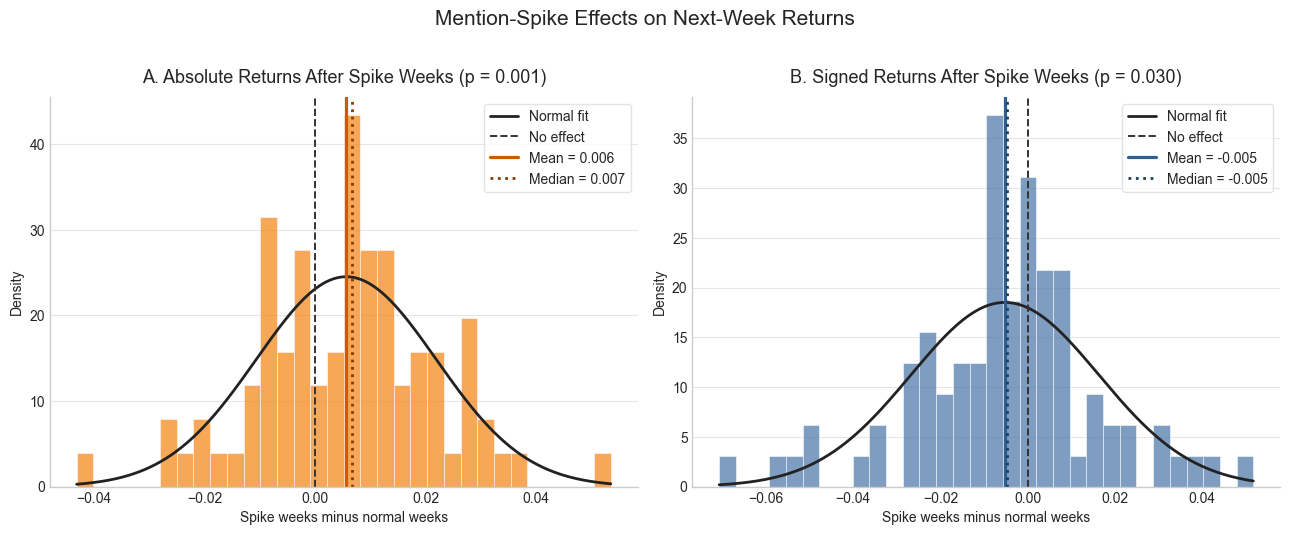

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')

abs_diff = ticker_effects['abs_return_diff'].dropna()
ret_diff = ticker_effects['return_diff'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

def add_hist_with_normal_fit(ax, data, color, mean_color, median_color, title, xlabel):
    mean = data.mean()
    median = data.median()
    std = data.std(ddof=1)

    ax.hist(
        data,
        bins=32,
        density=True,
        color=color,
        alpha=0.72,
        edgecolor='white',
        linewidth=0.5,
    )

    # Normal curve fitted with the same mean and standard deviation as the data.
    x = np.linspace(data.min(), data.max(), 400)
    normal_curve = stats.norm.pdf(x, loc=mean, scale=std)
    ax.plot(
        x,
        normal_curve,
        color='#222222',
        linewidth=2.0,
        label='Normal fit',
    )

    ax.axvline(0, color='#333333', linestyle='--', linewidth=1.4, label='No effect')
    ax.axvline(mean, color=mean_color, linewidth=2.3, label=f'Mean = {mean:.3f}')
    ax.axvline(median, color=median_color, linestyle=':', linewidth=2.0, label=f'Median = {median:.3f}')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(frameon=True, facecolor='white', edgecolor='#DDDDDD')


add_hist_with_normal_fit(
    axes[0],
    abs_diff,
    color='#F58518',
    mean_color='#C75D00',
    median_color='#8C3B00',
    title=f'A. Absolute Returns After Spike Weeks (p = {abs_test["p_value"]:.3f})',
    xlabel='Spike weeks minus normal weeks',
)

add_hist_with_normal_fit(
    axes[1],
    ret_diff,
    color='#4C78A8',
    mean_color='#2F5F8F',
    median_color='#1F3F5F',
    title=f'B. Signed Returns After Spike Weeks (p = {ret_test["p_value"]:.3f})',
    xlabel='Spike weeks minus normal weeks',
)

for ax in axes:
    ax.grid(axis='y', color='#E6E6E6')
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'Mention-Spike Effects on Next-Week Returns',
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.savefig(HERE / 'mention_spike_event_study_effects.png', dpi=180, bbox_inches='tight')
plt.show()

## 8. Largest ticker-level effects

In [20]:
cols = ['ticker', 'total_mentions', 'n_spike_weeks', 'threshold',
        'spike_abs_return_mean', 'normal_abs_return_mean', 'abs_return_diff',
        'spike_return_mean', 'normal_return_mean', 'return_diff']

ticker_effects.sort_values('abs_return_diff', ascending=False)[cols].head(15)

,ticker,total_mentions,n_spike_weeks,threshold,spike_abs_return_mean,normal_abs_return_mean,abs_return_diff,spike_return_mean,normal_return_mean,return_diff
69,CBA,27,3,4.0,0.160052,0.106522,0.053530,0.050517,-0.001295,0.051811
30,F,91,3,8.9,0.058962,0.023376,0.035586,-0.006091,-0.000753,-0.005338
57,GIS,35,3,4.0,0.053944,0.020862,0.033082,-0.034606,0.000380,-0.034986
25,JNJ,112,3,11.0,0.048166,0.016815,0.031351,-0.032107,0.002609,-0.034716
53,IRS,35,4,3.0,0.074960,0.044433,0.030527,-0.074960,-0.004179,-0.070780
45,BTI,46,3,5.0,0.054467,0.025539,0.028927,0.022441,-0.001123,0.023564
62,LMT,30,4,4.0,0.045923,0.017424,0.028499,-0.018692,0.003748,-0.022440
2,GOOGL,515,3,40.2,0.051231,0.022800,0.028430,-0.044389,0.004037,-0.048426
3,GS,405,3,33.1,0.054398,0.026094,0.028304,-0.036695,0.000608,-0.037303
67,MGA,28,3,3.0,0.054767,0.028043,0.026724,-0.024463,0.002277,-0.026741


## 9. Save outputs

In [21]:
ticker_effects.to_csv(HERE / 'mention_spike_ticker_effects.csv', index=False)
spike_events.to_csv(HERE / 'mention_spike_events.csv', index=False)
pd.Series(abs_test).to_csv(HERE / 'mention_spike_abs_return_test.csv')
pd.Series(ret_test).to_csv(HERE / 'mention_spike_signed_return_test.csv')

## Interpretation

The mention-spike event study shows that unusually high media attention is followed by significant changes in next-week stock behaviour.

For Test A, we test whether mention-spike weeks are followed by larger next-week absolute returns. The result is significant: the mean ticker-level difference is positive, and the one-sample t-test rejects the null hypothesis that the average effect is zero. The Wilcoxon robustness check gives the same conclusion. This means that, across the 84 tickers that pass the filters, stocks tend to move more in the week after a mention spike than after a normal week.

For Test B, we test signed next-week returns. The mean difference is negative and statistically significant, meaning that returns after spike weeks are lower on average than returns after normal weeks. However, this result should be interpreted more cautiously than Test A. Since we do not classify the sentiment of the articles, a mention spike can correspond to either good news or bad news. Therefore, the signed-return result does not prove that mention spikes are a reliable trading signal.

The main conclusion is that mention spikes are associated with larger subsequent price movements. There is also weaker evidence of negative next-week returns after spike weeks, but the strongest finding is about increased absolute returns, which suggests that bursts of media attention capture periods of higher market uncertainty or information arrival.